In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
num_pnts = 20
sample_virs = np.array(np.meshgrid(d_S*np.linspace(10, 100, num_pnts), # vary d_I
                                   K_IE*np.logspace(0.0, 2, num_pnts), # vary K_IE
                                   b_I*np.linspace(0.5, 2.0, num_pnts) # vary b_I
                                           )).T.reshape(-1,3)

# np.array(np.meshgrid(d_S*np.logspace(np.maximum(np.log10(1/sim_duration/d_S),1), 2.0, num_pnts), # vary d_I
#                                    K_IE*np.logspace(0.0, 3.0, num_pnts), # vary K_IE
#                                    b_I*np.logspace(-1, np.log10(2), num_pnts) # vary b_I
#                                            )).T.reshape(-1,3)

default_reg = act_psis + NM_psis + EM_psis + exp_psis

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"
# d="_local_data/"

In [3]:
# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample_virs, comment="single-reg-vary-virs", runs = 1, vir_model = "indep_harm", default_reg = default_reg, num_cpu = 36)

Running 8000 simulations in batch #-1
Saved sim_batch_-1-1-prim-single-reg-vary-virs.pkl


In [4]:
d_file = d + '/sim_batch_-1-1-prim-single-reg-vary-virs.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

n = len(sample_virs)
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
# dyn = data_dict["cell_time_series"]
# p_diff = data_dict["prim_diff_bias"]

In [34]:
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
sim_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).dropna(thresh=1)
use_data = sim_df.loc[sim_df['b_I']*sim_df['S_0'] >= sim_df['d_I']]
use_data.loc[:,'T_min_pI_corrected'] = sim_duration*(use_data['T_min_pI'].values == 0) + use_data['T_min_pI'].values

with pd.option_context('display.max_columns', None):
    display(use_data)

/tmp/ipykernel_54122/4238893346.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  use_data.loc[:,'T_min_pI_corrected'] = sim_duration*(use_data['T_min_pI'].values == 0) + use_data['T_min_pI'].values


,S_0,I_0,b_I,d_S,d_I,d_IE,d_IH,K_IE,K_IH,b_H,d_H,K_EI,K_EH,N_0,max_Na,b_myc,d_myc,myc_thresh,t_bind,t_unbind,t_Na_div,t_E_div,t_M_div,t_E_die,t_act,psi_Nact_I,psi_Nact_H,psi_Nact_IH,F0_Nact,psi_NM_I,psi_NM_H,psi_NM_IH,F0_NM,psi_EM_I,psi_EM_H,psi_EM_IH,F0_EM,psi_Ediv_I,psi_Ediv_H,psi_Ediv_IH,F0_Ediv,p_load,T_max_pI,T_min_pI,harm_pI,harm_pS,max_pE,T_pE_max,T_pE_start,inf_pM,init_M,int_pE,int_pH,min_pS,T_min_pI_corrected
0,10000000.0,1000.0,5.000000e-08,0.01,0.1,16.0,0.0,10000.000000,50000.0,1.0,2.0,10000.000000,50000.0,200.0,4.0,4.0,0.4,1.0,0.5,1.0,0.25,0.333333,0.5,2.5,0.25,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,8.368867e+06,21.0000,0.0000,8.481226e+05,922.641132,2022.0,21.0000,0.400102,194.0,30.0,8.979390e+02,3.640377e+05,6.673039e+06,21.0000
1,10000000.0,1000.0,5.000000e-08,0.01,0.1,16.0,0.0,12742.749857,50000.0,1.0,2.0,12742.749857,50000.0,200.0,4.0,4.0,0.4,1.0,0.5,1.0,0.25,0.333333,0.5,2.5,0.25,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,8.236938e+05,13.6500,0.0000,3.742517e+05,34007.103562,19009.0,14.4795,0.351435,12432.0,403.0,2.411255e+04,1.864779e+05,9.597074e+06,21.0000
2,10000000.0,1000.0,5.000000e-08,0.01,0.1,16.0,0.0,16237.767392,50000.0,1.0,2.0,16237.767392,50000.0,200.0,4.0,4.0,0.4,1.0,0.5,1.0,0.25,0.333333,0.5,2.5,0.25,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,7.321250e+06,21.0000,0.0000,1.055998e+06,25436.270911,17833.0,18.8265,1.114942,11748.0,315.0,2.081413e+04,4.794203e+05,7.004598e+06,21.0000
3,10000000.0,1000.0,5.000000e-08,0.01,0.1,16.0,0.0,20691.380811,50000.0,1.0,2.0,20691.380811,50000.0,200.0,4.0,4.0,0.4,1.0,0.5,1.0,0.25,0.333333,0.5,2.5,0.25,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,7.501238e+06,21.0000,0.0000,1.033568e+06,22159.134052,14839.0,19.0890,0.425093,11563.0,197.0,1.826154e+04,4.661574e+05,6.945609e+06,21.0000
4,10000000.0,1000.0,5.000000e-08,0.01,0.1,16.0,0.0,26366.508987,50000.0,1.0,2.0,26366.508987,50000.0,200.0,4.0,4.0,0.4,1.0,0.5,1.0,0.25,0.333333,0.5,2.5,0.25,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,8.383517e+06,21.0000,0.0000,8.357584e+05,10.774786,18.0,21.0000,0.175560,2.0,0.0,9.072000e+00,3.613073e+05,6.669176e+06,21.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,10000000.0,1000.0,2.000000e-07,0.01,1.0,16.0,0.0,379269.019073,50000.0,1.0,2.0,379269.019073,50000.0,200.0,4.0,4.0,0.4,1.0,0.5,1.0,0.25,0.333333,0.5,2.5,0.25,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,5.458538e+06,9.0090,11.6865,6.700818e+06,579021.414328,439957.0,12.1905,6.406523,618581.0,28801.0,1.130028e+06,3.350409e+06,3.151256e+06,11.6865
7996,10000000.0,1000.0,2.000000e-07,0.01,1.0,16.0,0.0,483293.023857,50000.0,1.0,2.0,483293.023857,50000.0,200.0,4.0,4.0,0.4,1.0,0.5,1.0,0.25,0.333333,0.5,2.5,0.25,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,5.929590e+06,9.0720,12.2535,7.014420e+06,460261.801803,377903.0,12.7470,7.175595,514030.0,19392.0,9.604406e+05,3.507210e+06,2.973315e+06,12.2535
7997,10000000.0,1000.0,2.000000e-07,0.01,1.0,16.0,0.0,615848.211066,50000.0,1.0,2.0,615848.211066,50000.0,200.0,4.0,4.0,0.4,1.0,0.5,1.0,0.25,0.333333,0.5,2.5,0.25,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,5.792618e+06,9.0510,12.2115,6.925299e+06,505218.348998,404764.0,12.7050,6.738375,559127.0,22399.0,1.035333e+06,3.462649e+06,3.012385e+06,12.2115
7998,10000000.0,1000.0,2.000000e-07,0.01,1.0,16.0,0.0,784759.970351,50000.0,1.0,2.0,784759.970351,50000.0,200.0,4.0,4.0,0.4,1.0,0.5,1.0,0.25,0.333333,0.5,2.5,0.25,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,6.083317e+06,9.0930,12.7260,7.110191e+06,422275.508619,275748.0,12.9675,6.443903,505760.0,33770.0,8.969233e+05,3.555095e+06,2.941591e+06,12.7260


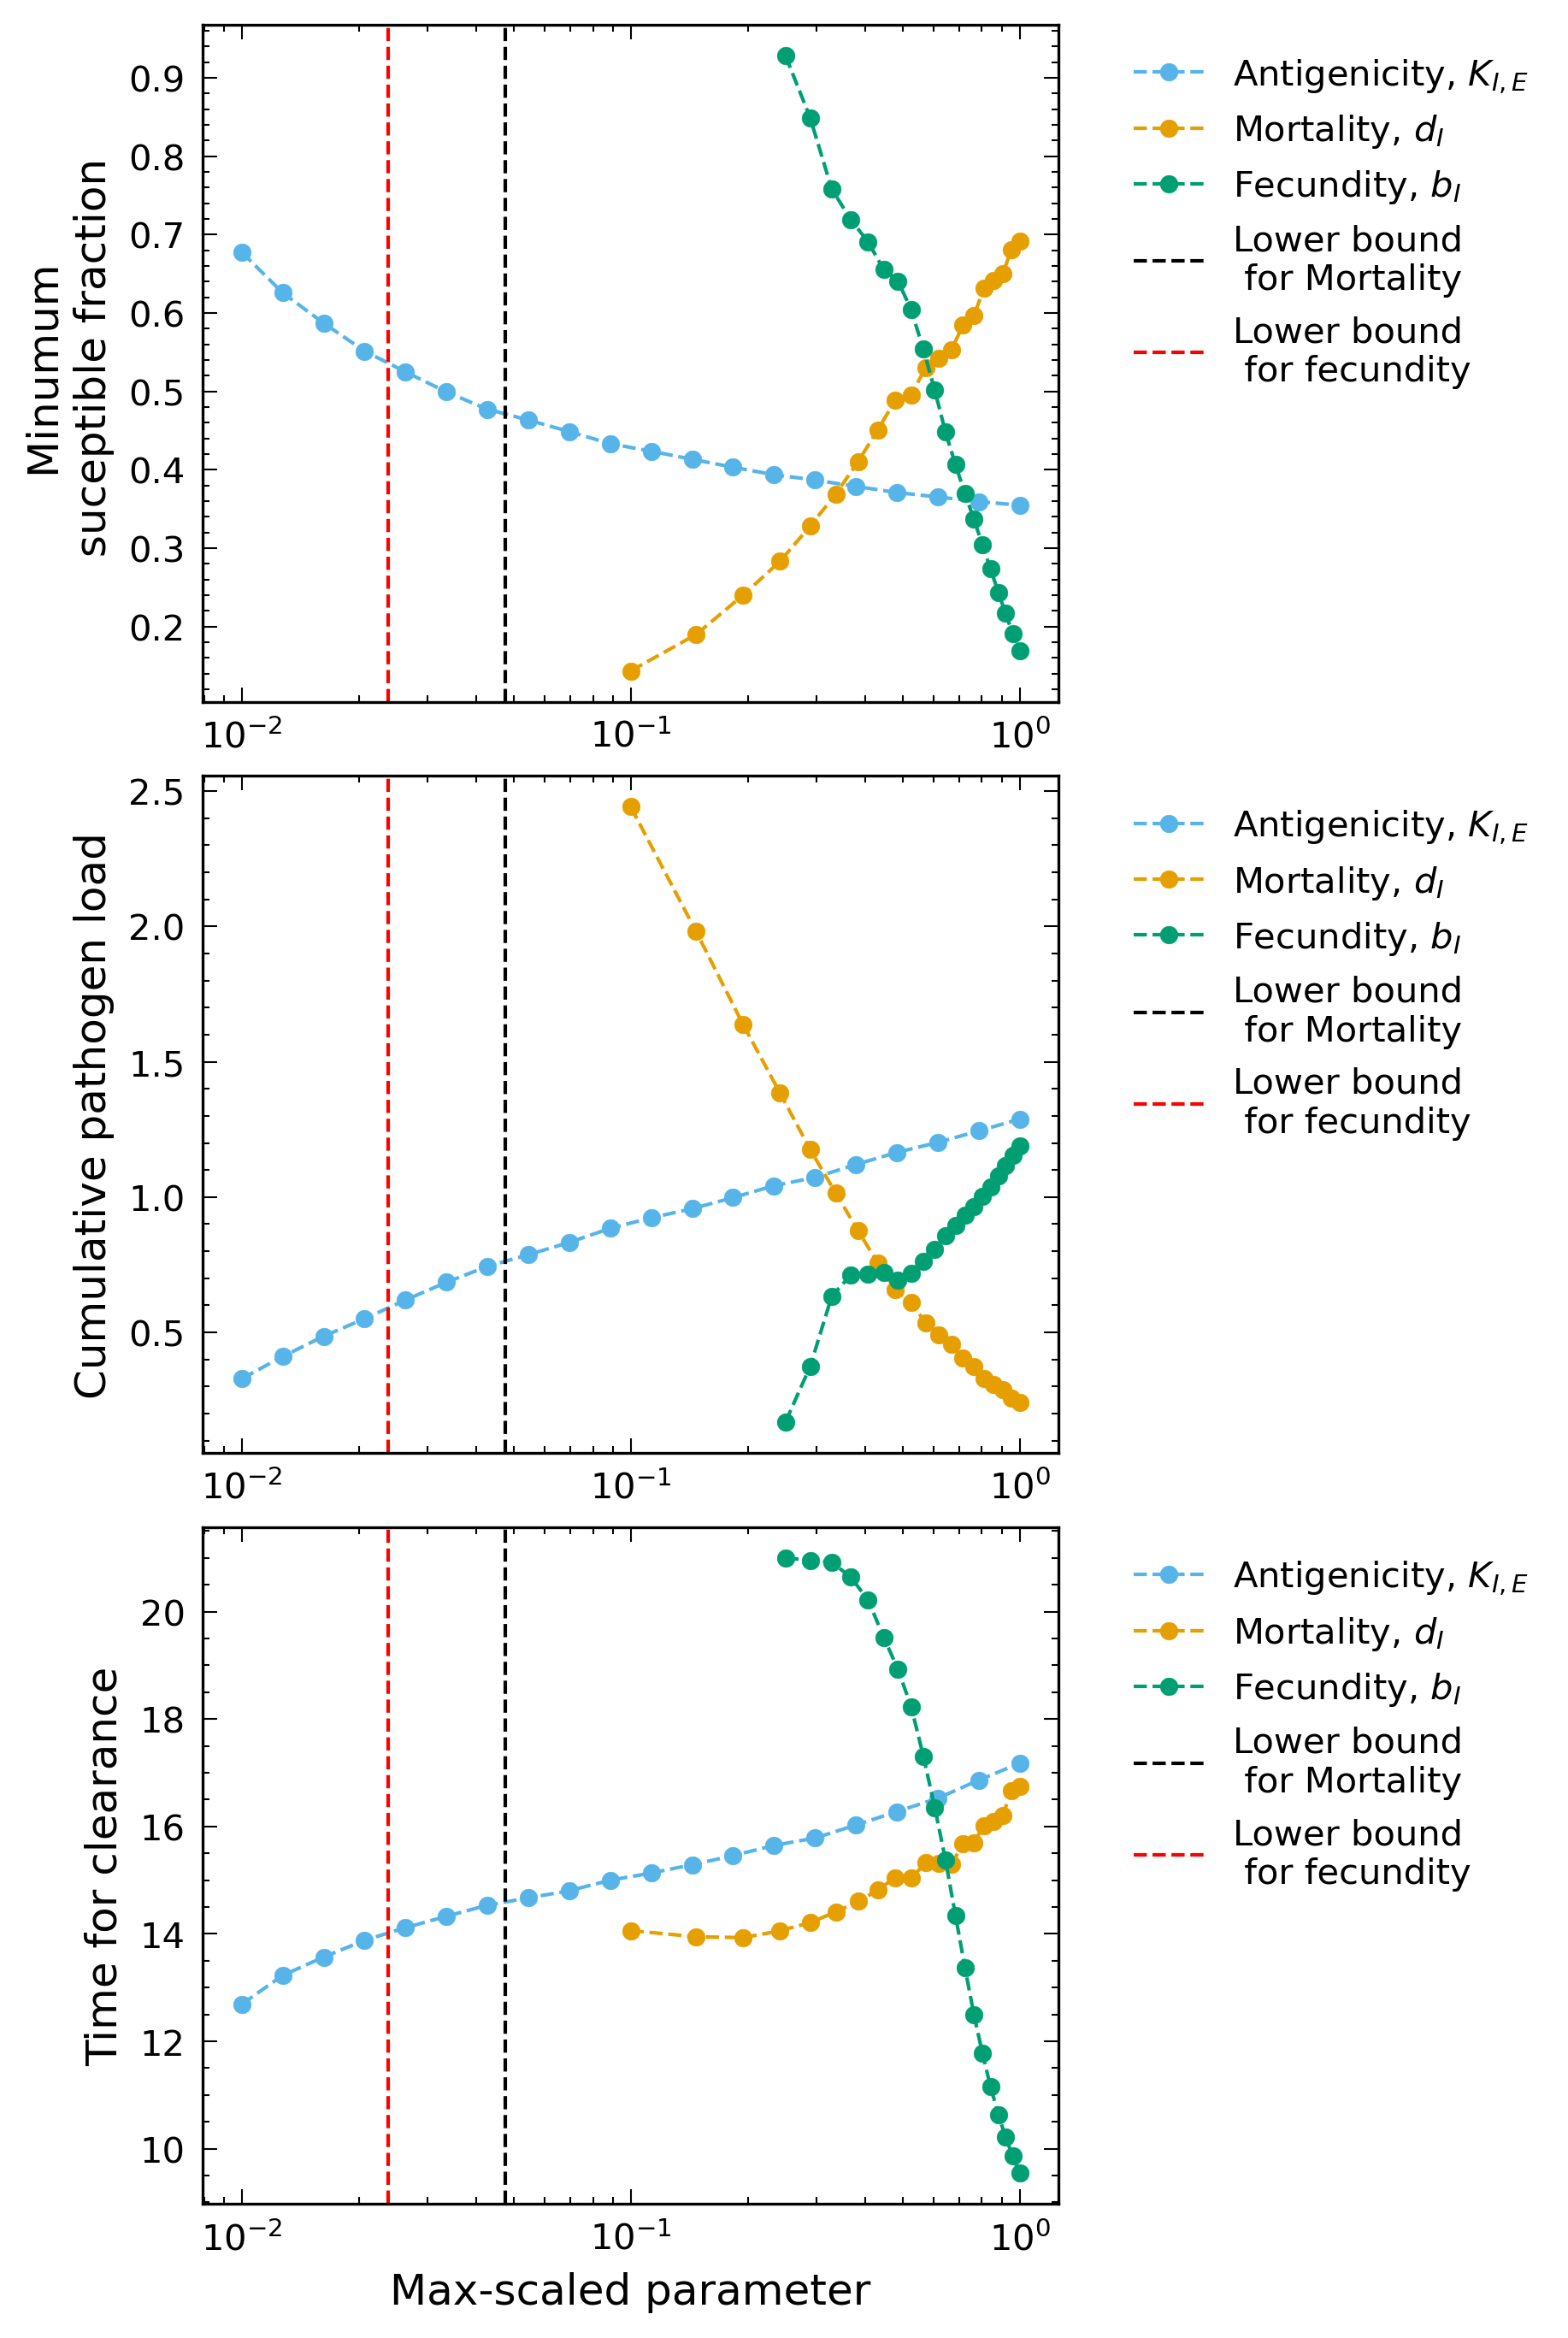

In [35]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))

ax1.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax1.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Mortality, $d_{I}$')
ax1.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax1.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Mortality")
ax1.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax1.semilogx()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax1.set(ylabel = 'Minumum \n suceptible fraction')

ax2.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax2.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Mortality, $d_{I}$')
ax2.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax2.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Mortality")
ax2.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax2.semilogx()
ax2.set(ylabel = 'Cumulative pathogen load')
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(use_data.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(use_data['K_IE']), use_data.groupby(['K_IE'], as_index=False).mean()['T_min_pI_corrected'], 'o--', label = 'Antigenicity, $K_{I,E}$')
ax3.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['T_min_pI_corrected'], 'o--', label = 'Mortality, $d_{I}$')
ax3.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['T_min_pI_corrected'], 'o--', label = 'Fecundity, $b_{I}$')
ax3.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Mortality")
ax3.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax3.set(ylabel = 'Time for clearance', xlabel = 'Max-scaled parameter')
ax3.semilogx()
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')


plt.savefig('_figs/vir_parameter_lineplots', dpi=300, bbox_inches='tight')

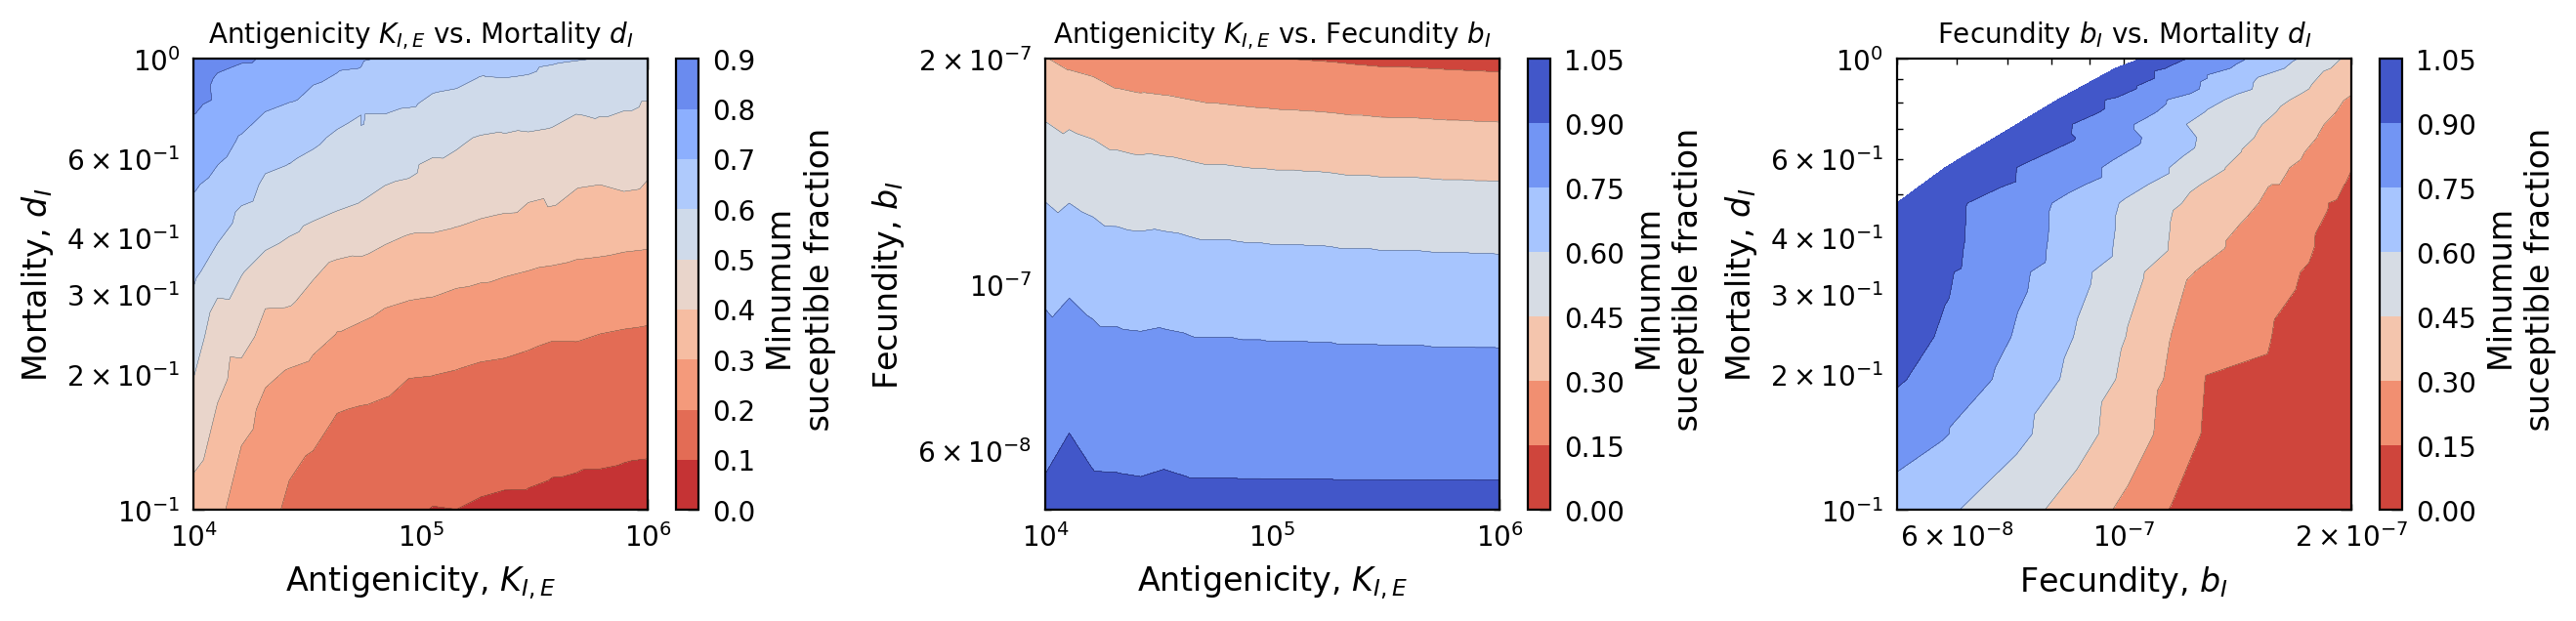

In [29]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

axs[0].tricontour(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                  use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im0 = axs[0].tricontourf(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                        use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[1].tricontour(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                  use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im1 = axs[1].tricontourf(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                        use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[2].tricontour(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im2 = axs[2].tricontourf(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r",norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Fecundity $b_I$ vs. Mortality $d_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 12)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_contour', dpi=300, bbox_inches='tight')

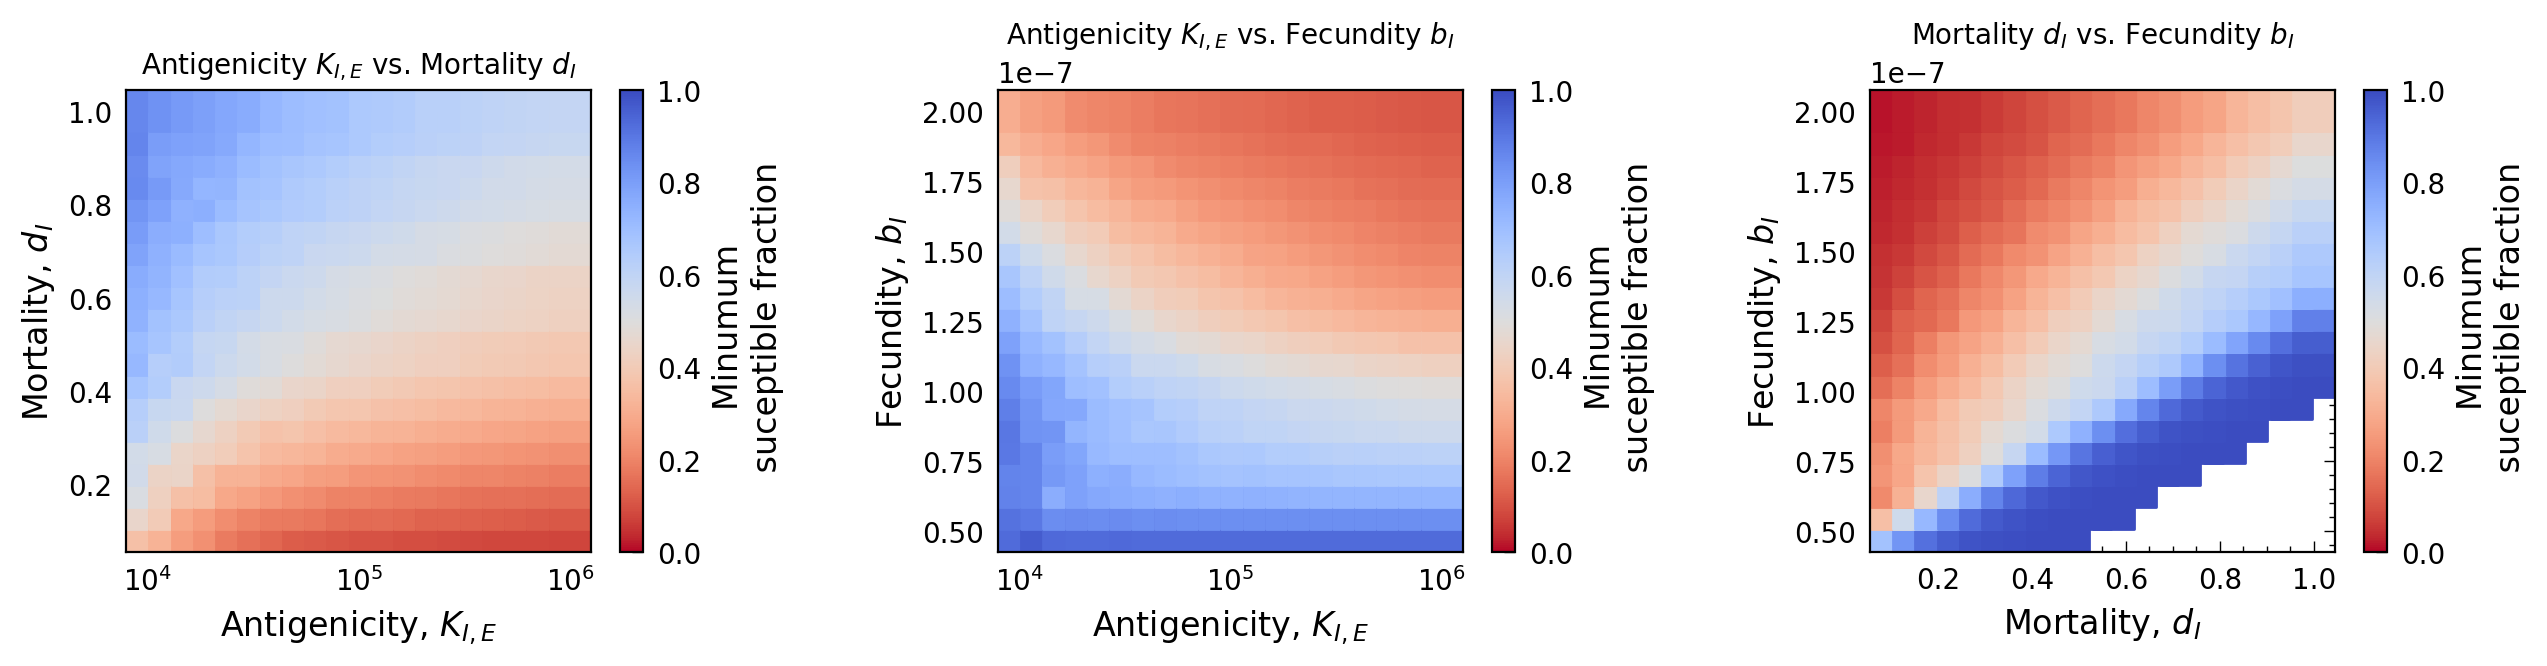

In [30]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

size = 4250/num_pnts

plot_data = use_data.groupby(['K_IE','d_I'], as_index=False).mean()
im0 = axs[0].scatter(plot_data['K_IE'], plot_data['d_I'], marker = 's', s = size,
                    c = plot_data['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
# axs[0].scatter(plot_data.loc[(plot_data['min_pS']/S_0 >= 0.485)*(plot_data['min_pS']/S_0 <= 0.515)]['K_IE'], plot_data.loc[(plot_data['min_pS']/S_0 >= 0.485)*(plot_data['min_pS']/S_0 <= 0.515)]['d_I'], marker = 'o', s = 5,
#                     color ='k')
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

plot_data = use_data.groupby(['K_IE','b_I'], as_index=False).mean()
im1 = axs[1].scatter(plot_data['K_IE'], plot_data['b_I'], marker = 's', s = size,
               c = plot_data['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

plot_data = use_data.groupby(['b_I','d_I'], as_index=False).mean()
im2 = axs[2].scatter(plot_data['d_I'], plot_data['b_I'], marker = 's', s = size,
               c = plot_data['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_heatmaps', dpi=300, bbox_inches='tight')

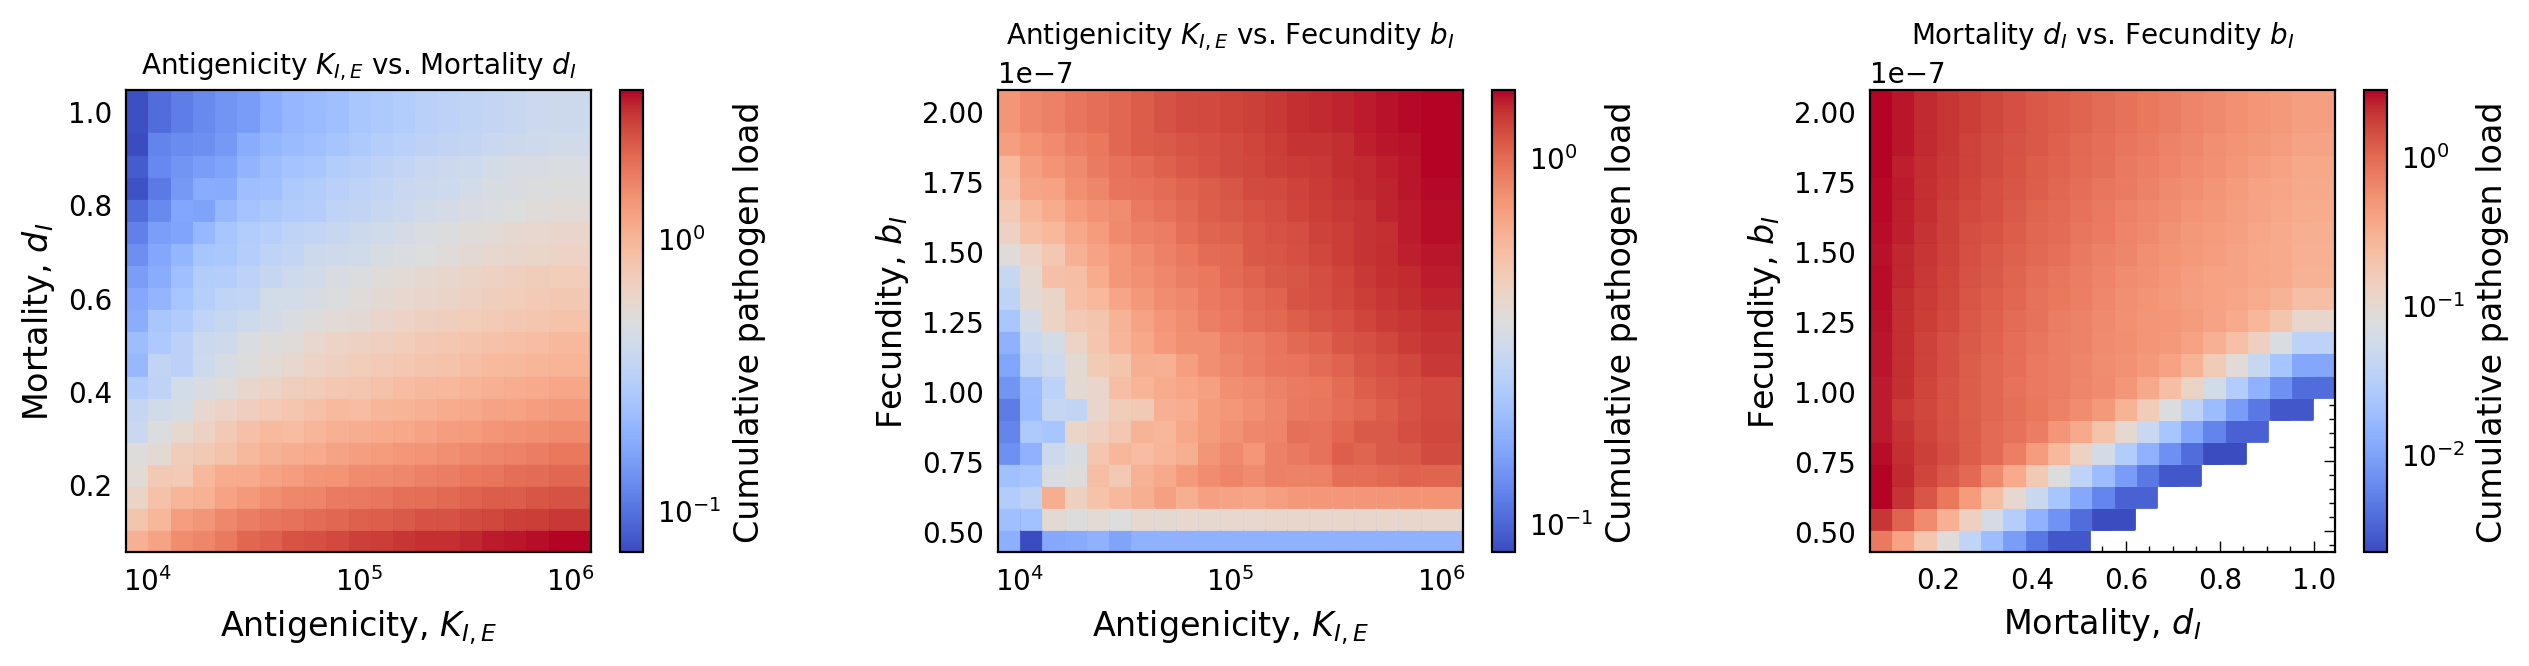

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['p_load']/S_0, cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_pharm_heatmaps', dpi=300, bbox_inches='tight')

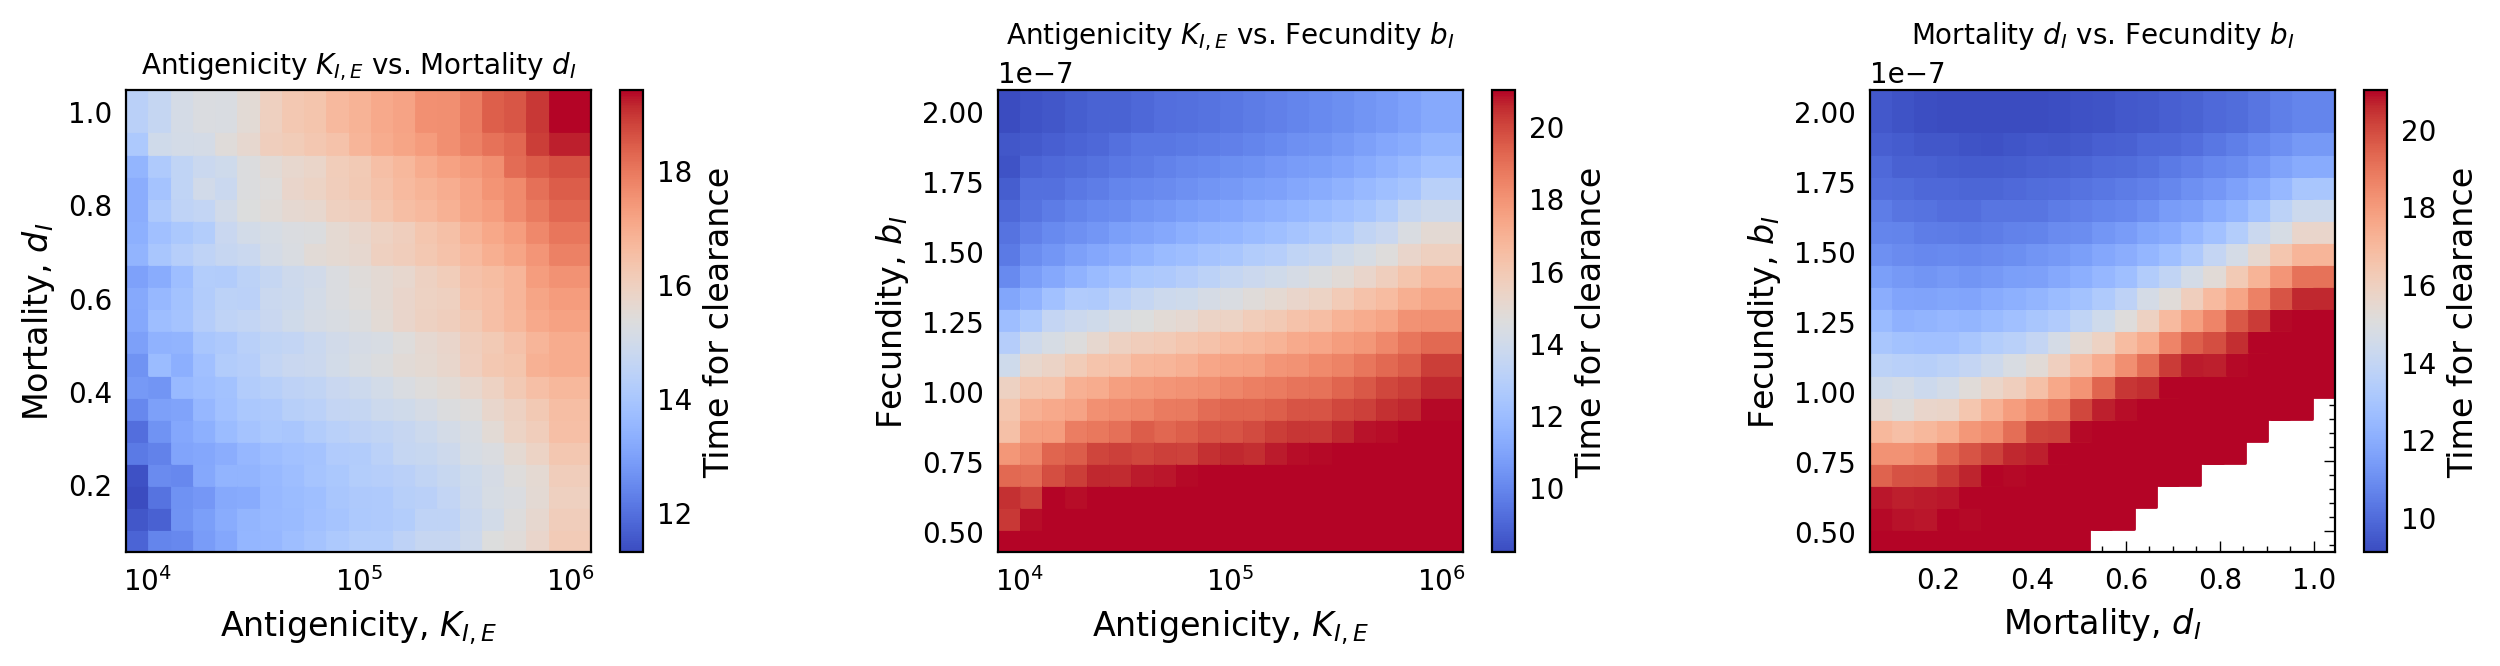

In [36]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['T_min_pI_corrected'], cmap='coolwarm')
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['T_min_pI_corrected'], cmap='coolwarm')
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['T_min_pI_corrected'], cmap='coolwarm')
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_ptiming_heatmaps', dpi=300, bbox_inches='tight')

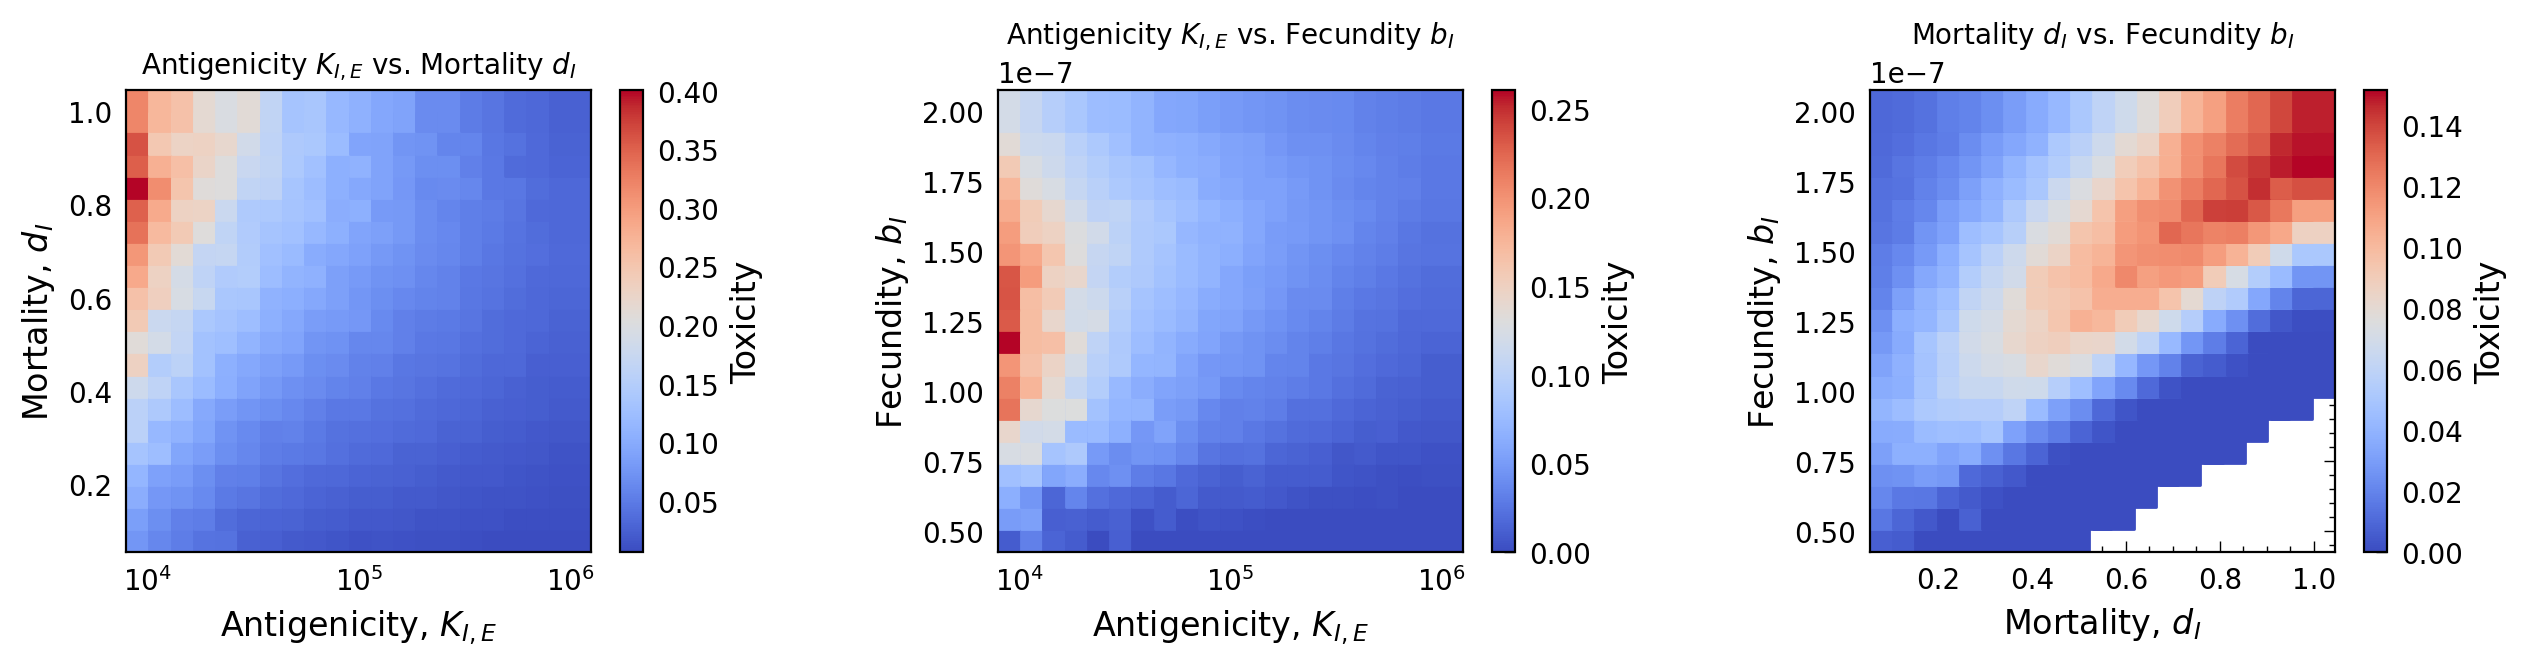

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_IE','d_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['K_IE','d_I'], as_index=False).mean()['harm_pI'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], use_data.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_IE','b_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['K_IE','b_I'], as_index=False).mean()['harm_pI'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pI'], cmap='coolwarm', norm=mpl.colors.Normalize())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Mortality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Mortality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Mortality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Mortality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_toxicity_heatmaps', dpi=300, bbox_inches='tight')